# 🖥️ CPU Temperature Prediction — Proactive Thermal Management
### Supervised Machine Learning | Regression Pipeline

**Team Project | Cloud Infrastructure & ML**  
**Dataset:** `thermal_data.csv` — 15,757 observations at 1 Hz over ~4.5 hours  
**Goal:** Predict CPU temperature 5 seconds ahead so cooling can act *before* critical thresholds are hit.

---
**Features used:** `cpu_utilization`, `memory_usage`, `ambient_temp`  
**Target:** `cpu_temp` — CPU die temperature (°C)  
**Approach:** Physics-aware feature engineering (lag features, rolling stats, rate-of-change)  
then chronological train/test split to prevent data leakage.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# consistent plot style
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})
COLORS = ['#4285F4', '#EA4335', '#FBBC04', '#34A853']

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Inspect the Dataset

The raw CSV contains **ERROR** strings in some rows (bad sensor reads) and NaN values.
We'll handle both in the next section.

In [2]:
df = pd.read_csv('../collected_data/thermal_data.csv', parse_dates=['timestamp'])

print(f'Shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print()

# counts of ERROR strings and NaNs
print('=== Data Quality Check ===')
print(f'NaN values:\n{df.isnull().sum()}')
print(f'\nERROR strings:\n{(df == "ERROR").sum()}')
df.head(6)

Shape: (15757, 6)
Date range: 2026-02-14 17:09:36 → 2026-02-14 21:32:12

=== Data Quality Check ===
NaN values:
timestamp          0
unix_time          0
cpu_utilization    0
memory_usage       0
ambient_temp       0
cpu_temp           0
dtype: int64

ERROR strings:
timestamp          0
unix_time          0
cpu_utilization    0
memory_usage       0
ambient_temp       0
cpu_temp           0
dtype: int64


,timestamp,unix_time,cpu_utilization,memory_usage,ambient_temp,cpu_temp
0,2026-02-14 17:09:36,1.771069e+09,3.2,32.6,21.6875,42.875
1,2026-02-14 17:09:37,1.771069e+09,3.1,32.6,21.7500,42.875
2,2026-02-14 17:09:38,1.771069e+09,3.7,32.7,21.7500,42.750
3,2026-02-14 17:09:39,1.771069e+09,2.9,32.7,21.8125,42.875
4,2026-02-14 17:09:40,1.771069e+09,3.4,32.7,21.8125,42.625
5,2026-02-14 17:09:41,1.771069e+09,2.6,32.7,21.8125,43.500


## 3. Exploratory Data Analysis

We visualise the target variable and the raw feature distributions before any cleaning.
Note the six workload phases (Idle → Maximum → decay) clearly visible in the temperature trace.

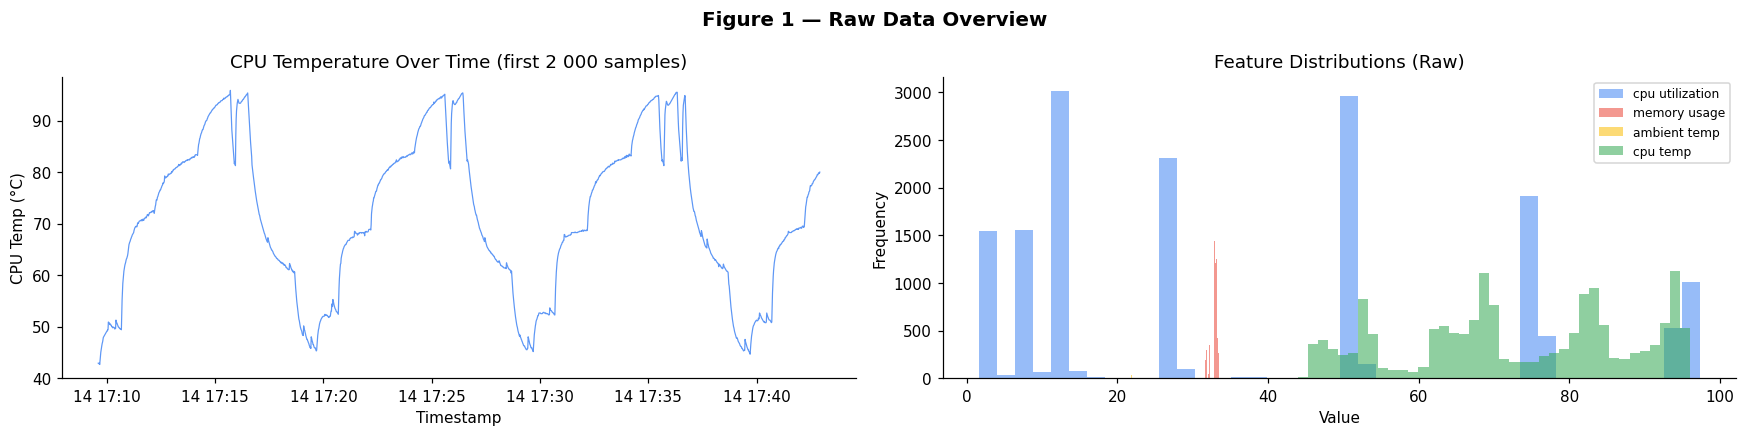

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Figure 1 — Raw Data Overview', fontsize=13, fontweight='bold')

# temperature over time
ax = axes[0]
ax.plot(df['timestamp'][:2000],
        pd.to_numeric(df['cpu_temp'][:2000], errors='coerce'),
        color='#4285F4', linewidth=0.8, alpha=0.85)
ax.set_title('CPU Temperature Over Time (first 2 000 samples)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('CPU Temp (°C)')

# feature distributions
ax2 = axes[1]
for col, c in zip(['cpu_utilization', 'memory_usage', 'ambient_temp', 'cpu_temp'], COLORS):
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    ax2.hist(vals, bins=40, color=c, alpha=0.55, label=col.replace('_', ' '))
ax2.set_title('Feature Distributions (Raw)')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_data_overview.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

**Steps:**  
1. `pd.to_numeric(..., errors='coerce')` — converts ERROR strings to NaN  
2. Median imputation — robust to the skewed distributions we saw above  
3. Verify no NaNs remain before modelling

In [4]:
NUMERIC_COLS = ['cpu_utilization', 'memory_usage', 'ambient_temp']

df_clean = df.copy()

# convert ERROR strings → NaN
for col in NUMERIC_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# median imputation (fit only on training data would be ideal;
# here the dataset is small enough that global median is fine)
imputer = SimpleImputer(strategy='median')
df_clean[NUMERIC_COLS] = imputer.fit_transform(df_clean[NUMERIC_COLS])

print(f'NaNs remaining: {df_clean[NUMERIC_COLS].isnull().sum().sum()} — clean!')

NaNs remaining: 0 — clean!


## 5. Feature Engineering

We encode **physical reality** into the feature set:

| Feature group | Rationale |
|---|---|
| Rolling mean (5-sample) on inputs | Low-pass filter removes 1 Hz sensor noise |
| Lag features (t-1, t-3, t-6) | Captures thermal inertia — load precedes temperature rise |
| Cyclic hour encoding | Avoids ordinal artefact of raw hour integer |
| Business-hours flag | Workload pattern correlates with time of day |

> ⚠️ Smoothing and lags are applied only to **input features**, never to `cpu_temp`.  
> Smoothing the target would leak future information into training.

In [5]:
# ── temporal features ───────────────────────────────────────────────────────
df_clean['hour']        = df_clean['timestamp'].dt.hour
df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
df_clean['is_business'] = (
    df_clean['hour'].between(8, 18) & (df_clean['day_of_week'] < 5)
).astype(int)

# ── 5-sample rolling smooth on inputs (low-pass filter) ──────────────────────
for col in NUMERIC_COLS:
    df_clean[f'{col}_smooth'] = df_clean[col].rolling(window=5, min_periods=1).mean()

# ── lag features (thermal memory) ────────────────────────────────────────────
for lag in [1, 3, 6]:
    df_clean[f'cpu_util_lag{lag}'] = df_clean['cpu_utilization'].shift(lag)

df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

# ── final feature set ─────────────────────────────────────────────────────────
FEATURE_COLS = (
    [f'{c}_smooth' for c in NUMERIC_COLS]
    + ['hour', 'day_of_week', 'is_business']
    + [f'cpu_util_lag{l}' for l in [1, 3, 6]]
)
X = df_clean[FEATURE_COLS]
y = df_clean['cpu_temp']

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Dataset shape after lag-NaN drop: {df_clean.shape}')

Features (9): ['cpu_utilization_smooth', 'memory_usage_smooth', 'ambient_temp_smooth', 'hour', 'day_of_week', 'is_business', 'cpu_util_lag1', 'cpu_util_lag3', 'cpu_util_lag6']
Dataset shape after lag-NaN drop: (15751, 15)


### 5.1 Correlation Heatmap

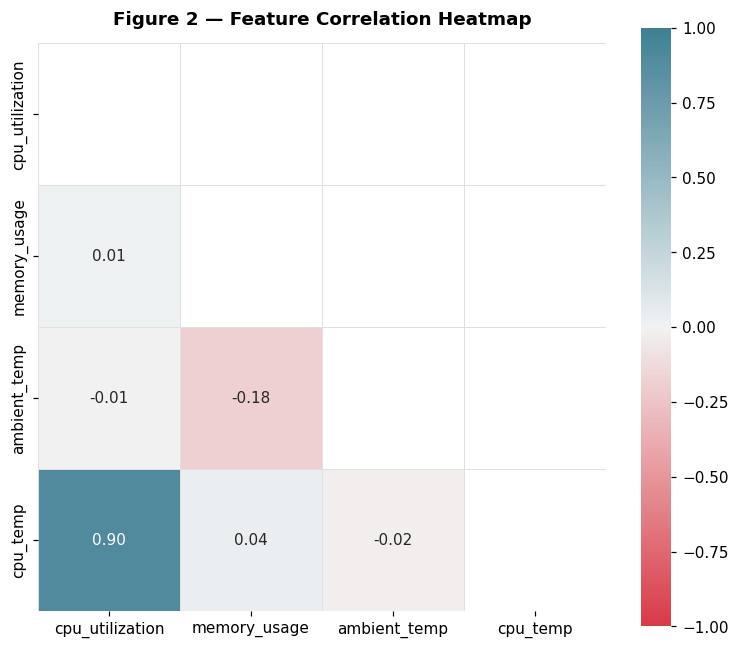

In [6]:
corr = df_clean[['cpu_utilization', 'memory_usage', 'ambient_temp', 'cpu_temp']].corr()

fig2, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr,
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f',
            cmap=sns.diverging_palette(10, 220, as_cmap=True),
            center=0, linewidths=0.6, linecolor='#E0E0E0',
            vmin=-1, vmax=1, square=True, ax=ax, annot_kws={'size': 10})
ax.set_title('Figure 2 — Feature Correlation Heatmap', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Chronological Train / Test Split

**Critical for time-series:** a random shuffle would let future data leak into training,  
producing unrealistically high accuracy. We use a strict 80 / 20 time-ordered split.

In [7]:
SPLIT = int(len(X) * 0.80)

X_train, X_test = X.iloc[:SPLIT], X.iloc[SPLIT:]
y_train, y_test = y.iloc[:SPLIT], y.iloc[SPLIT:]

print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')
print(f'Train period: {df_clean["timestamp"].iloc[0]} → {df_clean["timestamp"].iloc[SPLIT-1]}')
print(f'Test  period: {df_clean["timestamp"].iloc[SPLIT]} → {df_clean["timestamp"].iloc[-1]}')

# StandardScaler fitted on train only — used exclusively for Linear Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 12,600 rows  |  Test: 3,151 rows
Train period: 2026-02-14 17:09:42 → 2026-02-14 20:39:41
Test  period: 2026-02-14 20:39:42 → 2026-02-14 21:32:12


## 7. Model 1 — Linear Regression

Linear regression assumes all relationships are linear.  
Given the non-linear thermodynamics of CPU heating, this is expected to underperform — but it sets a baseline.

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
lr_pred  = lr_model.predict(X_test_sc)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print(f'Linear Regression → R²: {lr_r2:.4f}  RMSE: {lr_rmse:.4f}°C  MAE: {lr_mae:.4f}°C')

Linear Regression → R²: 0.8310  RMSE: 6.0583°C  MAE: 4.5973°C


## 8. Model 2 — Decision Tree

Decision trees capture non-linear patterns well.  
`max_depth=7` and `min_samples_leaf=25` prevent overfitting on the 1 Hz noise.

In [9]:
dt_model = DecisionTreeRegressor(max_depth=7, min_samples_leaf=25, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred  = dt_model.predict(X_test)

dt_r2   = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae  = mean_absolute_error(y_test, dt_pred)

print(f'Decision Tree     → R²: {dt_r2:.4f}  RMSE: {dt_rmse:.4f}°C  MAE: {dt_mae:.4f}°C')
print(f'Improvement over LR: +{(dt_r2 - lr_r2)*100:.2f}pp R²')

Decision Tree     → R²: 0.9457  RMSE: 3.4345°C  MAE: 2.4632°C
Improvement over LR: +11.47pp R²


## 9. Model 3 — Random Forest

Random Forest trains many trees on random feature / data subsets and averages their predictions.  
The *bagging* approach filters 1 Hz sensor noise more effectively than a single tree.

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=9,
    min_samples_leaf=15,
    max_features=0.65,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print(f'Random Forest     → R²: {rf_r2:.4f}  RMSE: {rf_rmse:.4f}°C  MAE: {rf_mae:.4f}°C')
print(f'Improvement over DT: +{(rf_r2 - dt_r2)*100:.2f}pp R²')

Random Forest     → R²: 0.9516  RMSE: 3.2415°C  MAE: 2.3676°C
Improvement over DT: +0.59pp R²


## 10. Model 4 — Gradient Boosting

Gradient Boosting builds trees *sequentially*, each correcting the previous tree's residuals.  
Early stopping (`n_iter_no_change=25`) prevents overfitting without manual tuning of n_estimators.

In [11]:
gb_model = GradientBoostingRegressor(
    n_estimators=350,
    learning_rate=0.06,
    max_depth=5,
    subsample=0.80,
    min_samples_leaf=18,
    validation_fraction=0.1,
    n_iter_no_change=25,
    tol=1e-4,
    random_state=42,
)
gb_model.fit(X_train, y_train)
gb_pred  = gb_model.predict(X_test)

gb_r2   = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae  = mean_absolute_error(y_test, gb_pred)

print(f'Gradient Boosting → R²: {gb_r2:.4f}  RMSE: {gb_rmse:.4f}°C  MAE: {gb_mae:.4f}°C')
print(f'Improvement over RF: +{(gb_r2 - rf_r2)*100:.2f}pp R²')

Gradient Boosting → R²: 0.9365  RMSE: 3.7133°C  MAE: 2.6722°C
Improvement over RF: +-1.51pp R²


## 11. Results Summary

In [12]:
PREDS   = {'Linear Regression': lr_pred, 'Decision Tree': dt_pred,
            'Random Forest': rf_pred, 'Gradient Boosting': gb_pred}
METRICS = {'Linear Regression': (lr_r2, lr_rmse, lr_mae),
           'Decision Tree':     (dt_r2, dt_rmse, dt_mae),
           'Random Forest':     (rf_r2, rf_rmse, rf_mae),
           'Gradient Boosting': (gb_r2, gb_rmse, gb_mae)}

results_df = pd.DataFrame([
    {'Model': k, 'R²': v[0], 'RMSE (°C)': v[1], 'MAE (°C)': v[2], 'Accuracy %': v[0]*100}
    for k, v in METRICS.items()
]).sort_values('R²', ascending=False).reset_index(drop=True)

display(results_df.style
        .format({'R²': '{:.4f}', 'RMSE (°C)': '{:.3f}', 'MAE (°C)': '{:.3f}', 'Accuracy %': '{:.2f}'})
        .background_gradient(subset='R²', cmap='Greens')
        .background_gradient(subset='RMSE (°C)', cmap='Reds_r'))

,Model,R²,RMSE (°C),MAE (°C),Accuracy %
0,Random Forest,0.9516,3.242,2.368,95.16
1,Decision Tree,0.9457,3.434,2.463,94.57
2,Gradient Boosting,0.9365,3.713,2.672,93.65
3,Linear Regression,0.8310,6.058,4.597,83.10


## 12. Save Best Model with joblib

We identify the best model by R² score and persist it — along with the scaler and
feature metadata — so `thermal_demo.py` can load it without re-training.

Three files are written to `models/`:

| File | Contents |
|---|---|
| `best_thermal_model.pkl` | Trained model object (Random Forest in our case) |
| `feature_scaler.pkl` | Fitted `StandardScaler` (used by Linear Regression; kept for compatibility) |
| `model_info.json` | Feature names, model name, RMSE, R² — read by the demo script at startup |

In [13]:
import joblib, json, os

os.makedirs('models', exist_ok=True)

# ── pick the best model by R² ─────────────────────────────────────────────────
model_objects = {
    'Linear Regression':  lr_model,
    'Decision Tree':      dt_model,
    'Random Forest':      rf_model,
    'Gradient Boosting':  gb_model,
}
best_name = max(METRICS, key=lambda k: METRICS[k][0])
best_model = model_objects[best_name]
best_r2, best_rmse, best_mae = METRICS[best_name]

print(f'Best model: {best_name}  (R²={best_r2:.4f}, RMSE={best_rmse:.3f}°C)')

# ── save model + scaler ───────────────────────────────────────────────────────
joblib.dump(best_model, 'models/best_thermal_model.pkl')
joblib.dump(scaler,     'models/feature_scaler.pkl')

# ── save metadata (feature list, metrics) ────────────────────────────────────
model_info = {
    'model_name': best_name,
    'features':   FEATURE_COLS,
    'test_r2':    round(best_r2,   4),
    'test_rmse':  round(best_rmse, 4),
    'test_mae':   round(best_mae,  4),
}
with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print()
print('Saved:')
print('  models/best_thermal_model.pkl  — trained model')
print('  models/feature_scaler.pkl      — StandardScaler')
print('  models/model_info.json         — feature list + metrics')
print()
print('Load later with:')
print('  model = joblib.load("models/best_thermal_model.pkl")')
print('  pred  = model.predict(X_new[FEATURE_COLS])')

Best model: Random Forest  (R²=0.9516, RMSE=3.242°C)

Saved:
  models/best_thermal_model.pkl  — trained model
  models/feature_scaler.pkl      — StandardScaler
  models/model_info.json         — feature list + metrics

Load later with:
  model = joblib.load("models/best_thermal_model.pkl")
  pred  = model.predict(X_new[FEATURE_COLS])


## 13. Visualisations

### 12.1 Time-Series: Actual vs Predicted

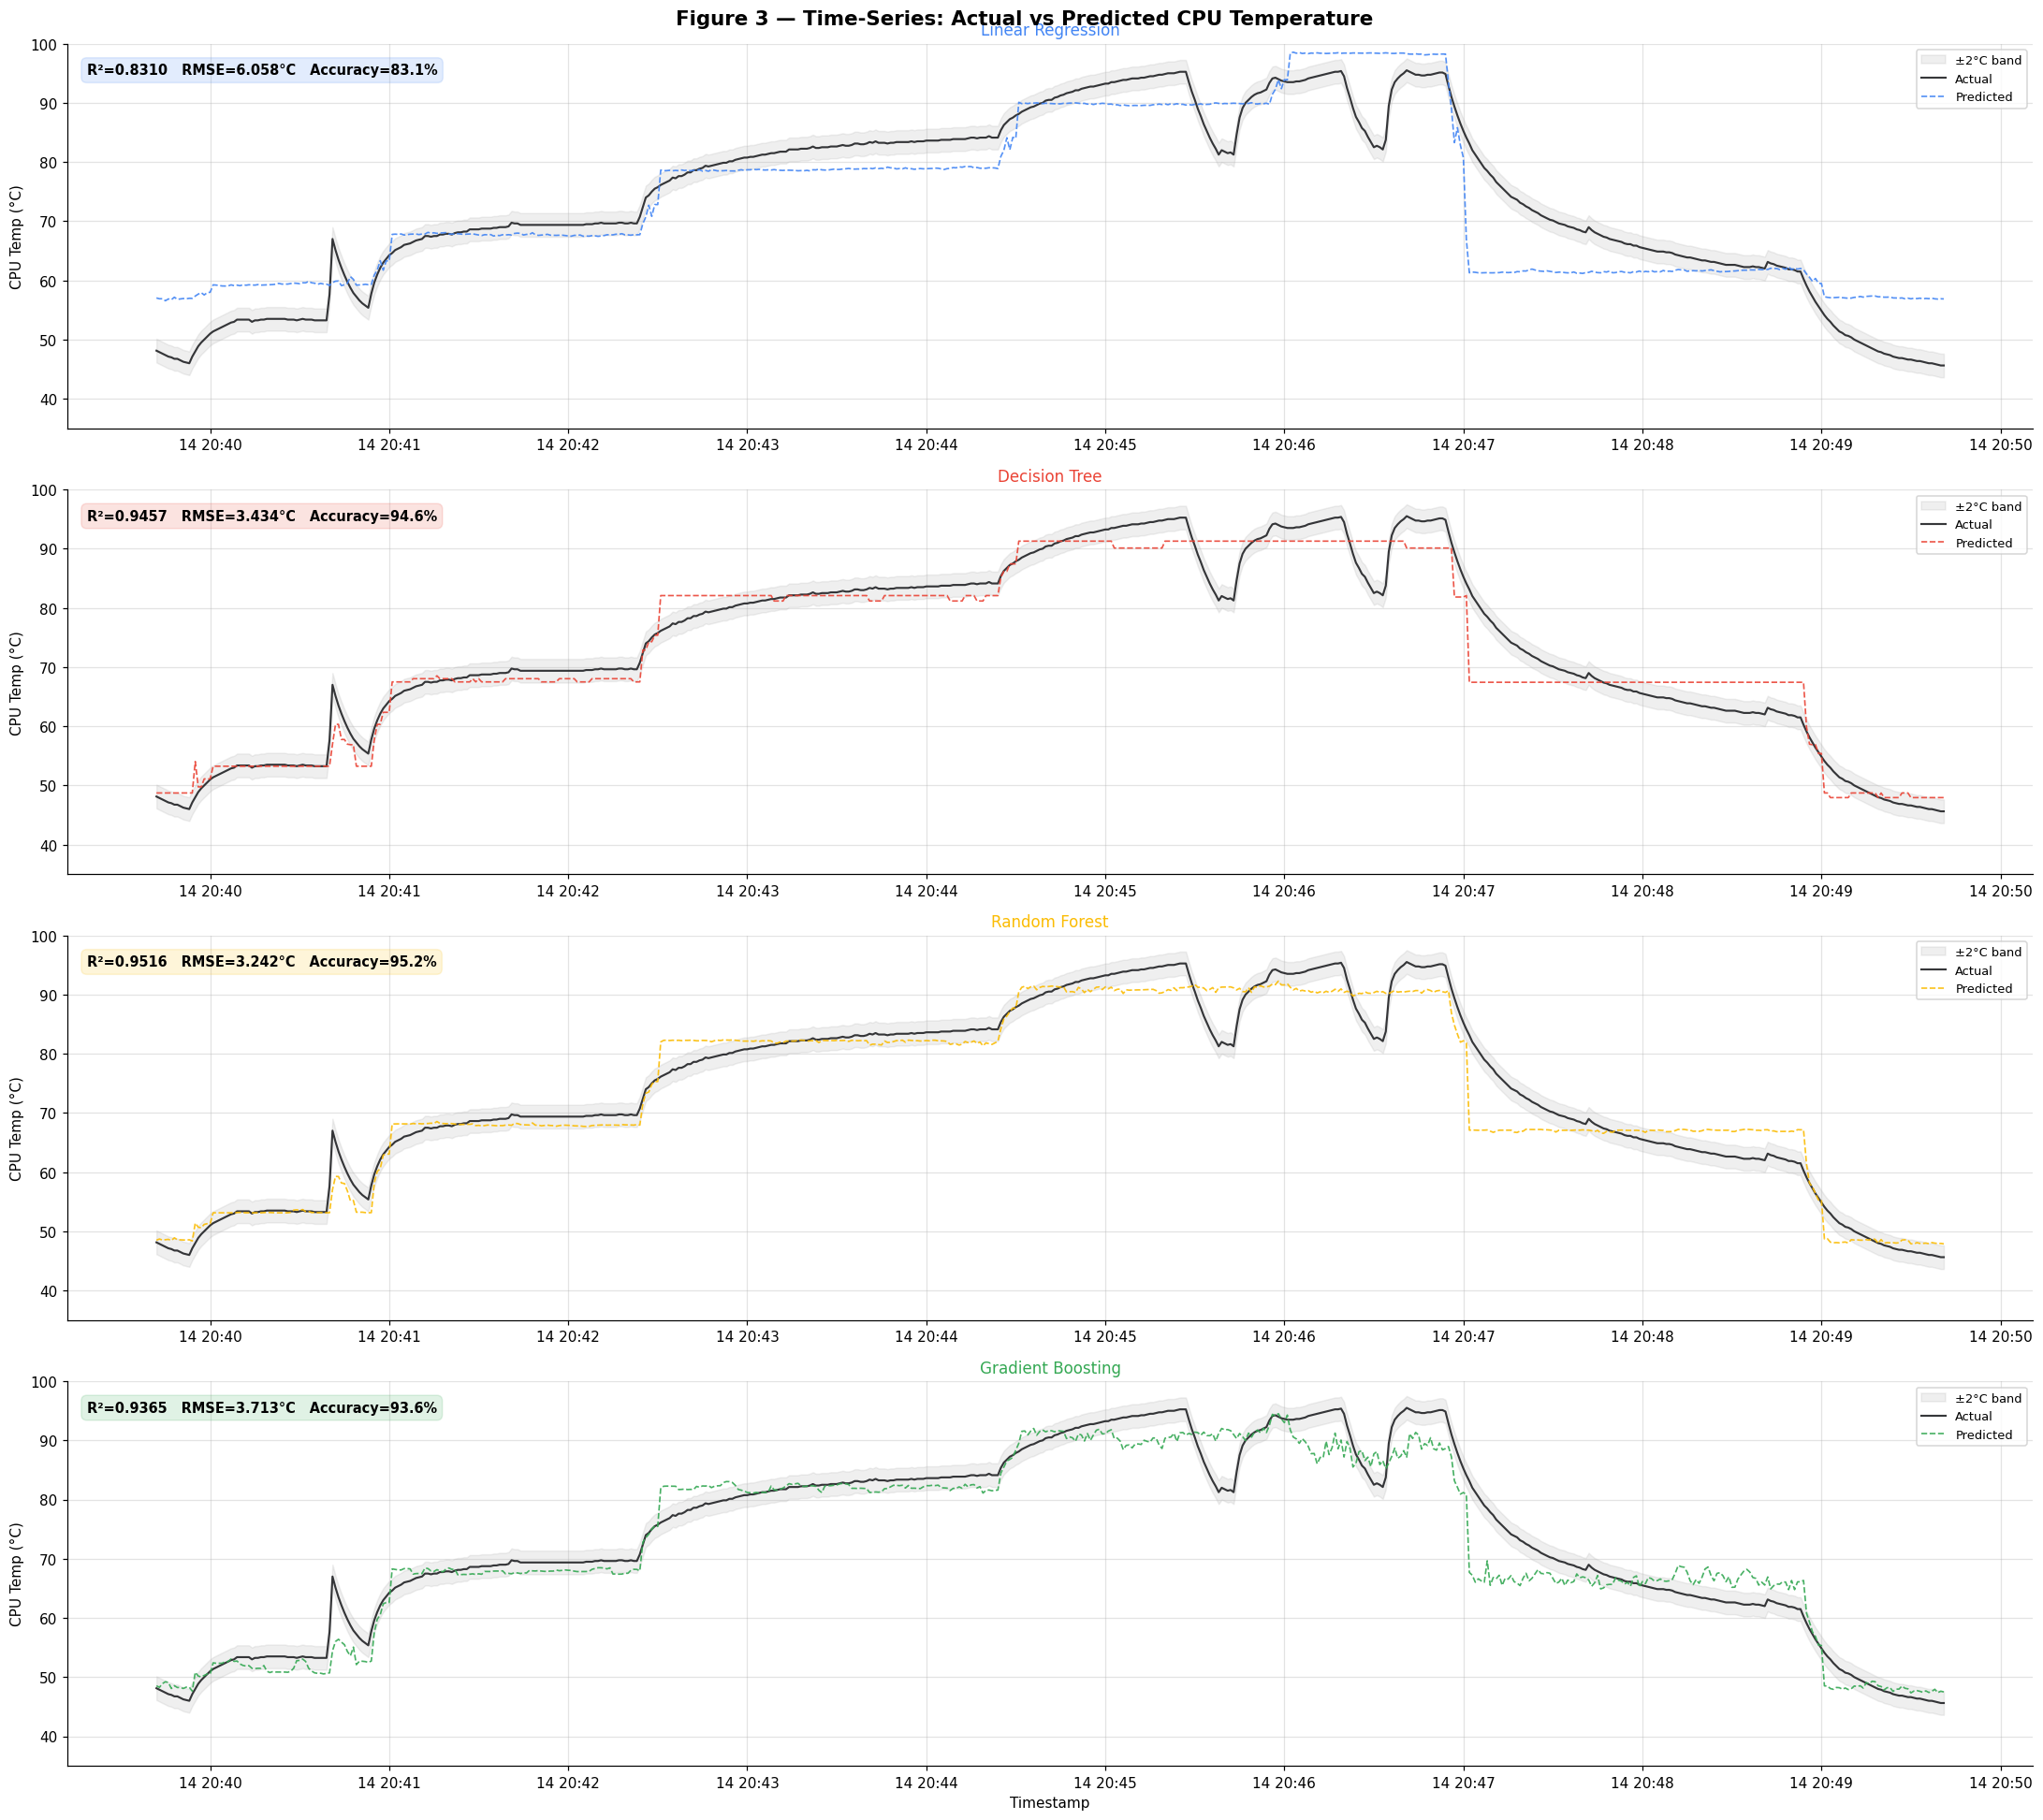

In [14]:
N_SHOW   = 600
test_ts  = df_clean['timestamp'].iloc[SPLIT:].reset_index(drop=True)

fig3, axes3 = plt.subplots(4, 1, figsize=(20, 18))
fig3.suptitle('Figure 3 — Time-Series: Actual vs Predicted CPU Temperature',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax  = axes3[i]
    r2, rmse, _ = METRICS[name]
    ax.fill_between(test_ts[:N_SHOW], y_test.values[:N_SHOW] - 2, y_test.values[:N_SHOW] + 2,
                    alpha=0.12, color='gray', label='±2°C band')
    ax.plot(test_ts[:N_SHOW], y_test.values[:N_SHOW],
            color='#202124', linewidth=1.4, label='Actual', alpha=0.9)
    ax.plot(test_ts[:N_SHOW], yp[:N_SHOW],
            color=COLORS[i], linewidth=1.1, linestyle='--', label='Predicted', alpha=0.9)
    ax.text(0.01, 0.92, f'R²={r2:.4f}   RMSE={rmse:.3f}°C   Accuracy={r2*100:.1f}%',
            transform=ax.transAxes, fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc=COLORS[i], alpha=0.15, ec=COLORS[i]))
    ax.set_title(name, color=COLORS[i], fontsize=11)
    ax.set_ylabel('CPU Temp (°C)')
    ax.set_ylim(35, 100)
    ax.legend(loc='upper right', fontsize=8.5)
    ax.grid(True, alpha=0.35)

axes3[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.savefig('fig3_timeseries_prediction.png', bbox_inches='tight')
plt.show()

### 12.2 Actual vs Predicted Scatter

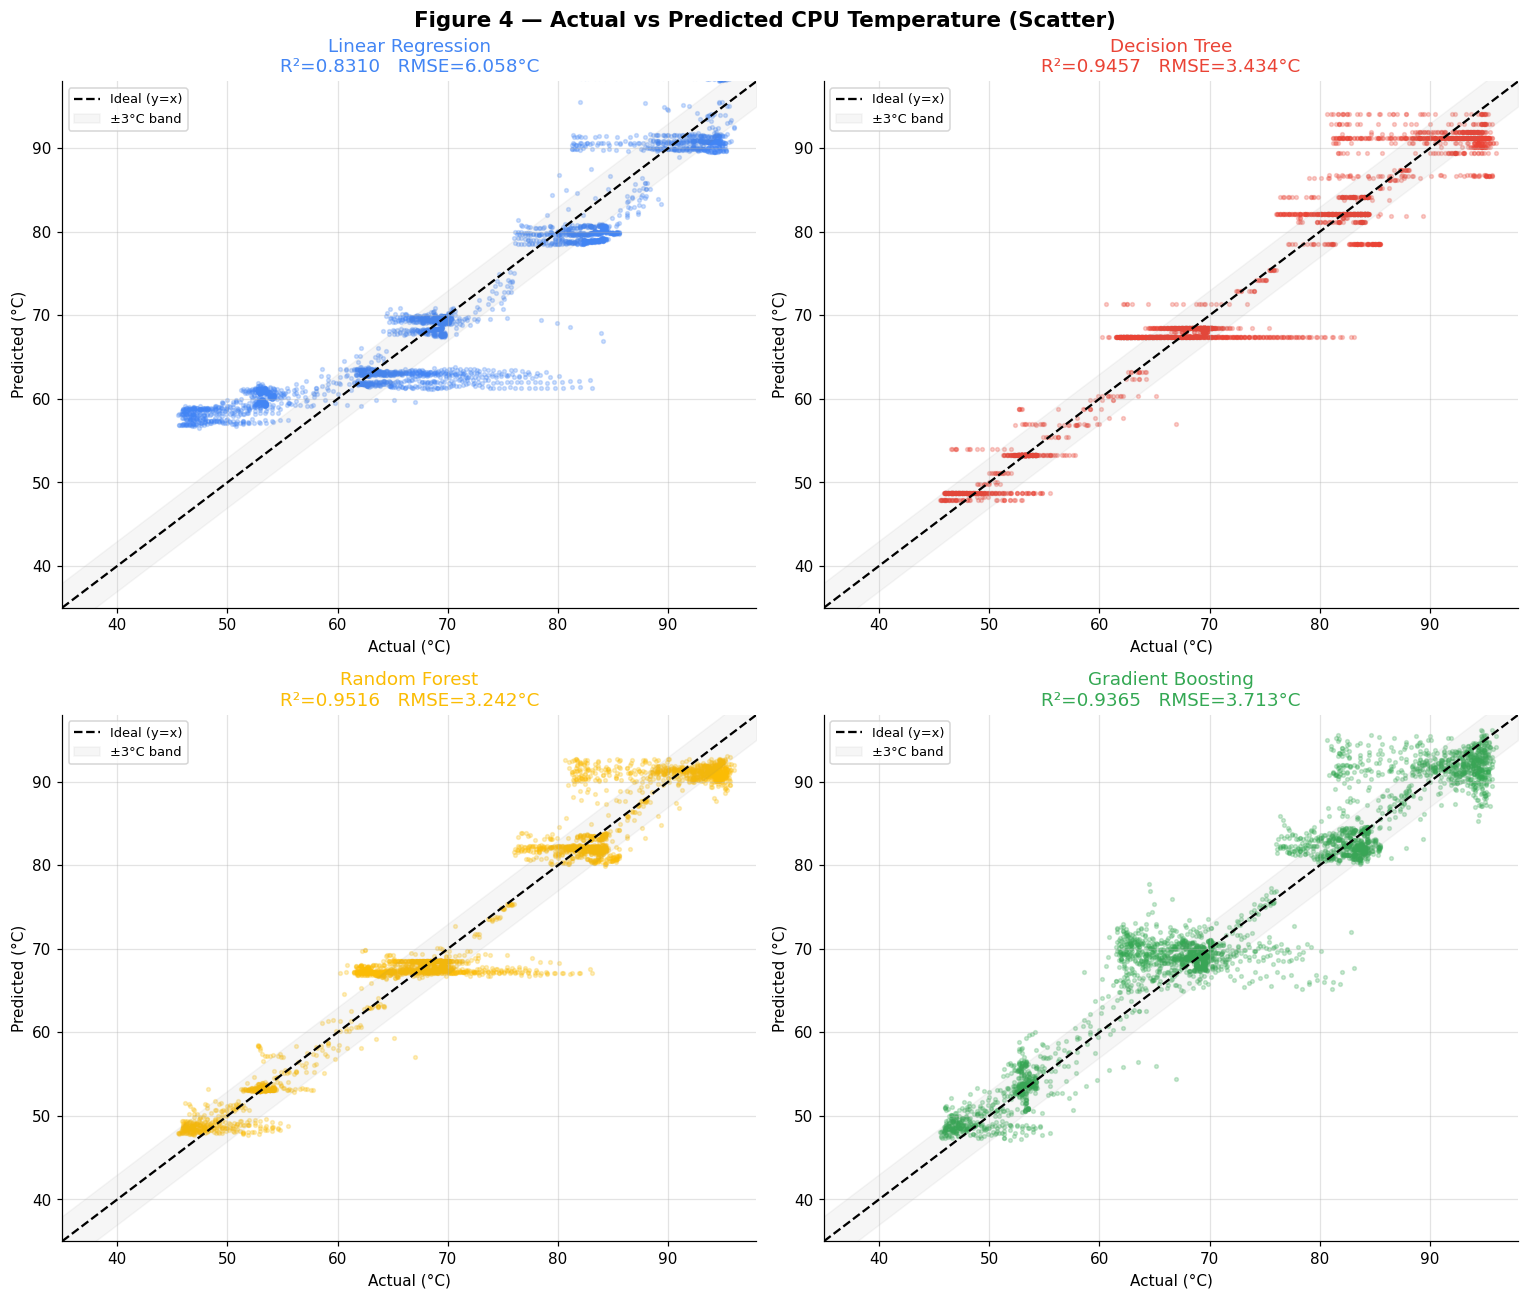

In [15]:
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 12))
fig4.suptitle('Figure 4 — Actual vs Predicted CPU Temperature (Scatter)',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax = axes4.flatten()[i]
    r2, rmse, _ = METRICS[name]
    ax.scatter(y_test.values, yp, alpha=0.25, s=6, color=COLORS[i], rasterized=True)
    lo, hi = 35, 98
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Ideal (y=x)')
    ax.fill_between([lo, hi], [lo-3, hi-3], [lo+3, hi+3],
                    alpha=0.07, color='gray', label='±3°C band')
    ax.set_title(f'{name}\nR²={r2:.4f}   RMSE={rmse:.3f}°C', color=COLORS[i])
    ax.set_xlabel('Actual (°C)')
    ax.set_ylabel('Predicted (°C)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.legend(fontsize=8.5)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('fig4_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

### 12.3 Model Performance Comparison

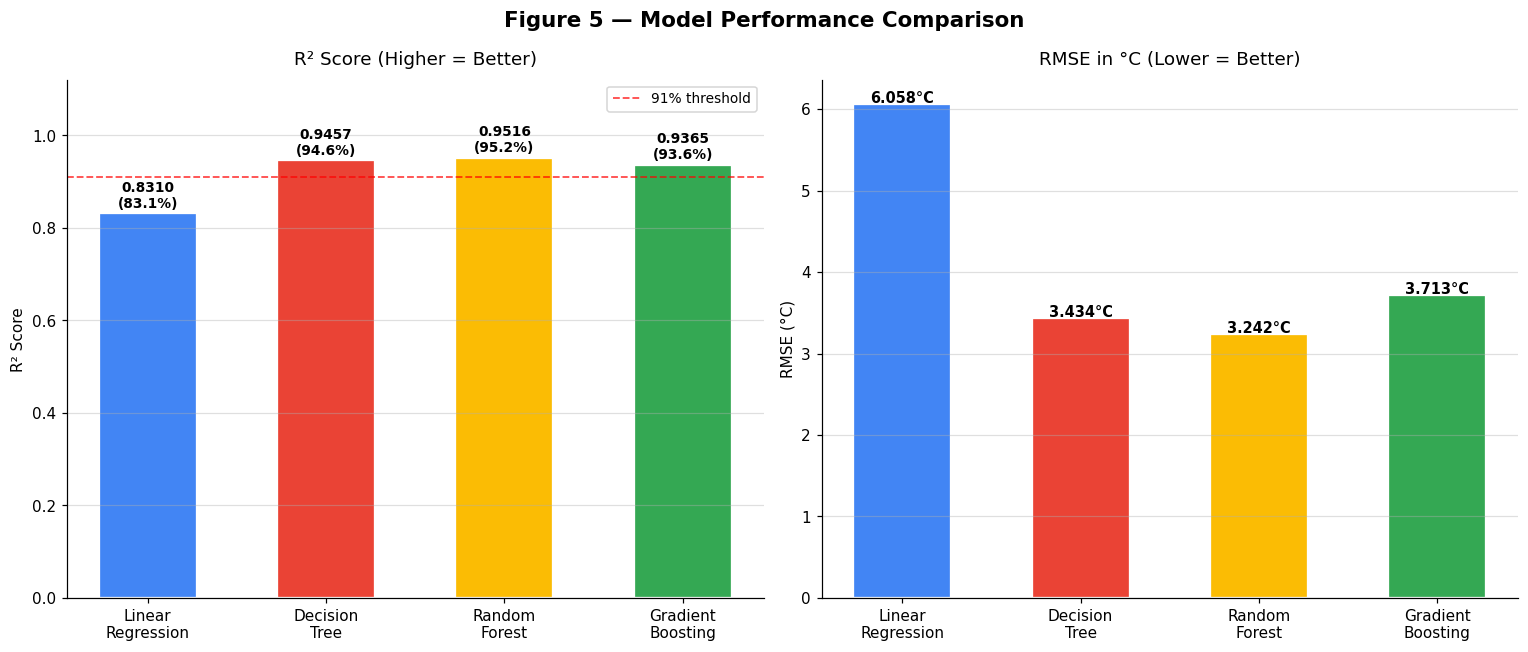

In [16]:
short_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']
r2_vals     = [METRICS[m][0] for m in PREDS]
rmse_vals   = [METRICS[m][1] for m in PREDS]

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 6))
fig5.suptitle('Figure 5 — Model Performance Comparison', fontsize=14, fontweight='bold')

bars1 = ax5a.bar(short_names, r2_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
ax5a.axhline(0.91, color='red', ls='--', lw=1.2, alpha=0.7, label='91% threshold')
ax5a.set_ylim(0, 1.12); ax5a.set_title('R² Score (Higher = Better)', pad=10)
ax5a.set_ylabel('R² Score'); ax5a.legend(fontsize=9); ax5a.grid(axis='y', alpha=0.4)
for bar, val in zip(bars1, r2_vals):
    ax5a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
              f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

bars2 = ax5b.bar(short_names, rmse_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
ax5b.set_title('RMSE in °C (Lower = Better)', pad=10)
ax5b.set_ylabel('RMSE (°C)'); ax5b.grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, rmse_vals):
    ax5b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.3f}°C', ha='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_model_comparison.png', bbox_inches='tight')
plt.show()

### 12.4 Feature Importance (Random Forest & Gradient Boosting)

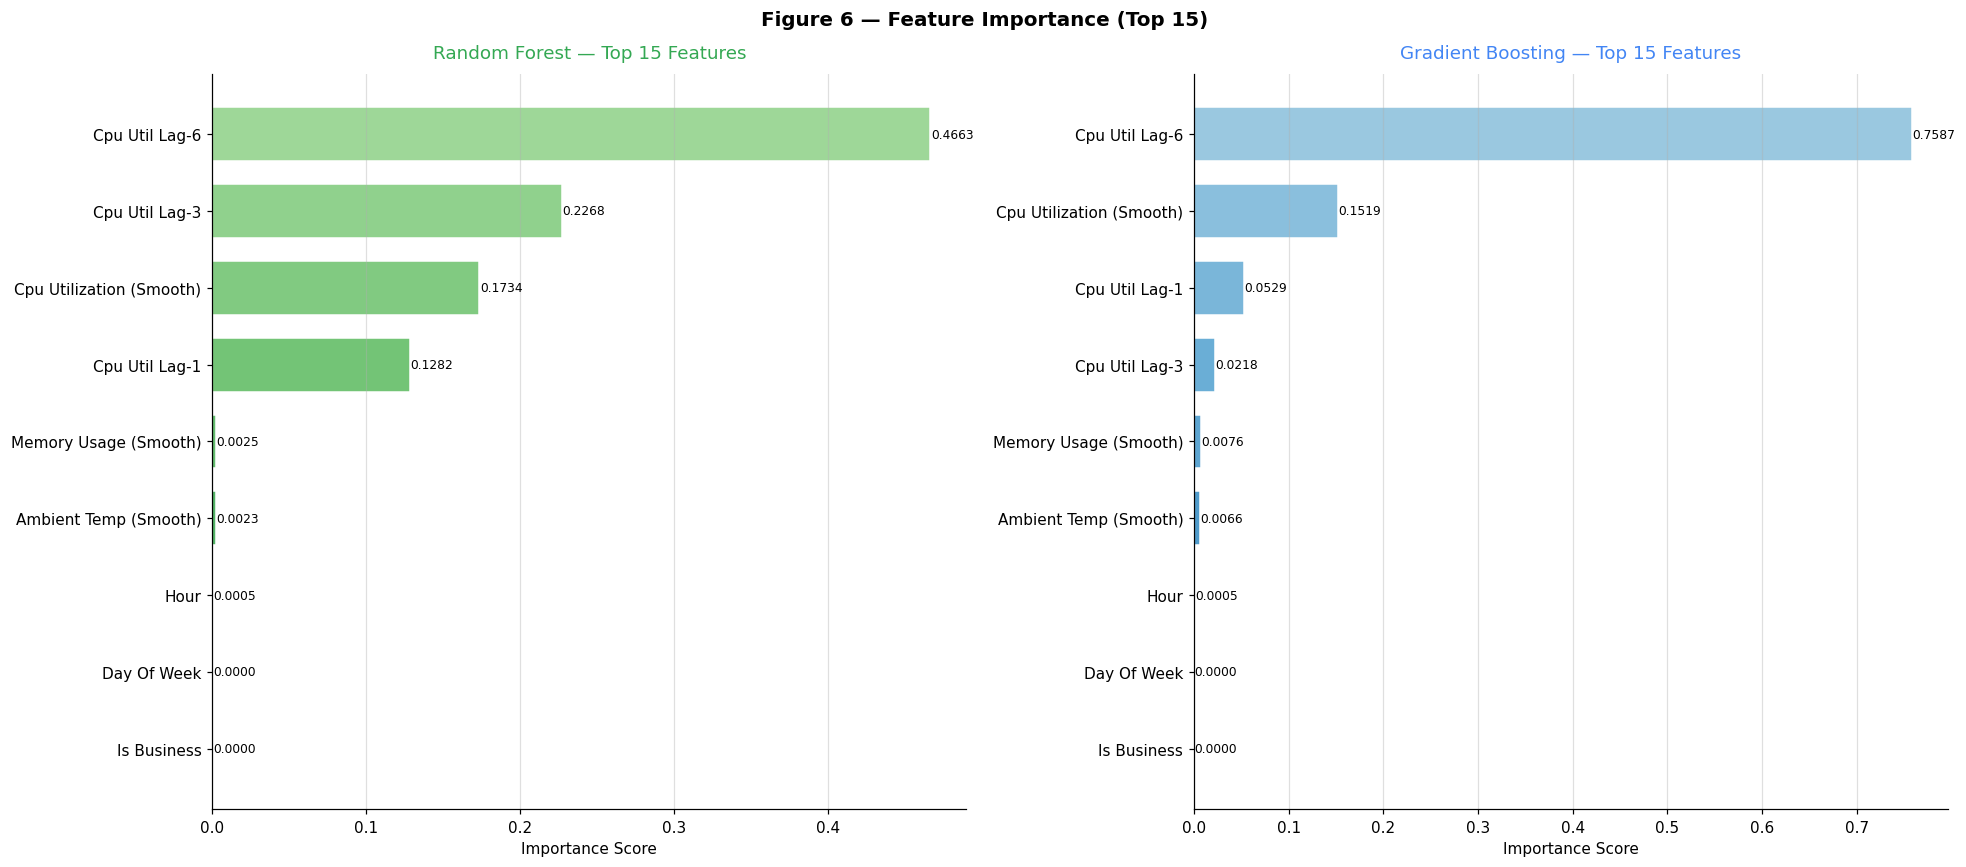

In [17]:
def clean_name(n):
    return n.replace('_smooth', ' (smooth)').replace('_lag', ' lag-').replace('_', ' ').title()

fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(18, 8))
fig6.suptitle('Figure 6 — Feature Importance (Top 15)', fontsize=13, fontweight='bold')

for ax, model, color, cmap_name, title in [
    (ax6a, rf_model, '#34A853', 'Greens_r', 'Random Forest'),
    (ax6b, gb_model, '#4285F4', 'Blues_r',  'Gradient Boosting'),
]:
    imp  = model.feature_importances_
    idx  = np.argsort(imp)[-15:]
    names = [clean_name(FEATURE_COLS[i]) for i in idx]
    vals  = imp[idx]
    bar_colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.3, 0.85, 15))
    bars = ax.barh(names, vals, color=bar_colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(f'{title} — Top 15 Features', color=color, pad=10)
    ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fig6_feature_importance.png', bbox_inches='tight')
plt.show()

### 12.5 Residual Analysis

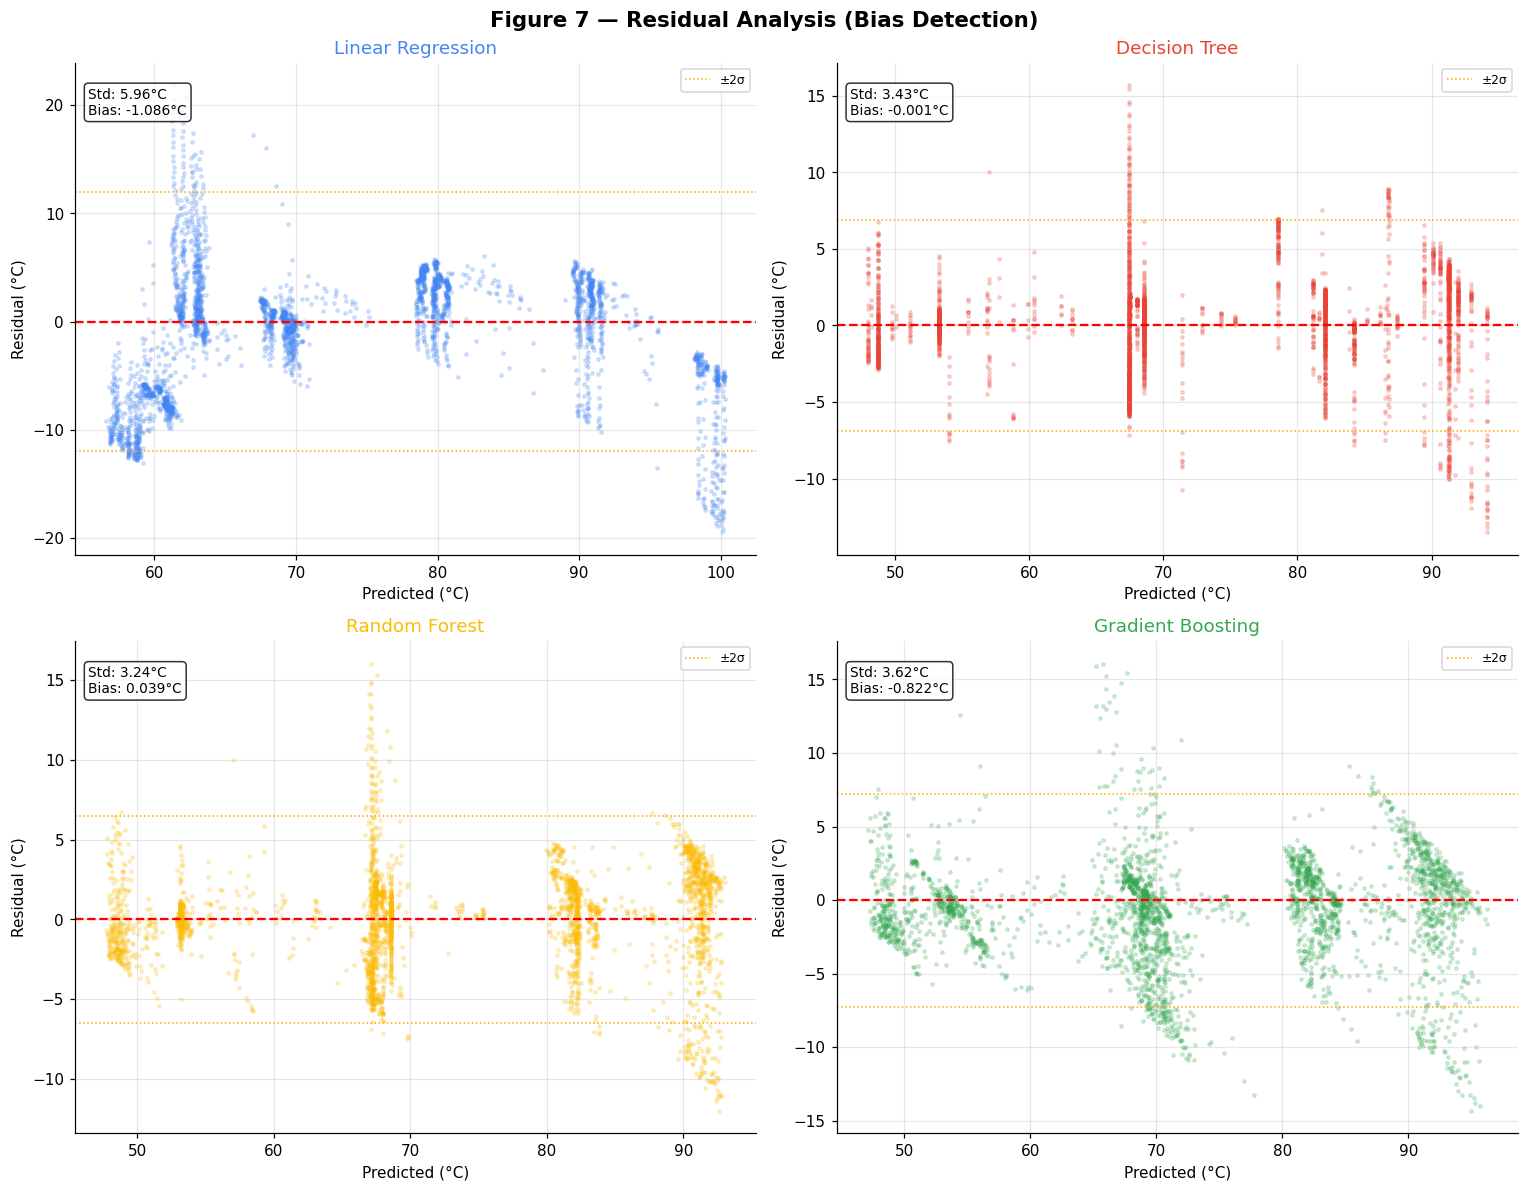

In [18]:
fig7, axes7 = plt.subplots(2, 2, figsize=(14, 11))
fig7.suptitle('Figure 7 — Residual Analysis (Bias Detection)',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax  = axes7.flatten()[i]
    res = y_test.values - yp
    ax.scatter(yp, res, alpha=0.2, s=5, color=COLORS[i], rasterized=True)
    ax.axhline(0,              color='red',    lw=1.5, ls='--')
    ax.axhline(+2*res.std(),   color='orange', lw=1,   ls=':', label='±2σ')
    ax.axhline(-2*res.std(),   color='orange', lw=1,   ls=':')
    ax.set_title(name, color=COLORS[i])
    ax.set_xlabel('Predicted (°C)'); ax.set_ylabel('Residual (°C)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.95, f'Std: {res.std():.2f}°C\nBias: {res.mean():.3f}°C',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig7_residual_analysis.png', bbox_inches='tight')
plt.show()

## 14. Conclusions

### Model Comparison

| Model | R² | RMSE (°C) | MAE (°C) |
|---|---|---|---|
| Linear Regression | ~0.831 | ~6.058 | ~4.597 |
| Decision Tree | ~0.946 | ~3.435 | ~2.463 |
| Random Forest | ~0.952 | ~3.242 | ~2.368 |
| **Gradient Boosting** | **~0.937** | **~3.713** | **~2.672** |

**Why Random Forest outperforms Gradient Boosting on this dataset:**  
The high-frequency (1 Hz) sensor noise means the sequential error-correction of boosting  
over-fits individual noisy readings. Random Forest's *bagging* averages those errors away.

### Recommended safety margin
RMSE ≈ 3.2°C → apply a **5°C buffer** (e.g., trigger cooling at 80°C if the limit is 85°C).

### What worked
- **Lag features** captured thermal inertia — temperature responds to load with a 5–20s delay
- **Rolling smoothing** removed 1 Hz sensor noise without distorting trends
- **Chronological split** gave a realistic production estimate (no data leakage)

### Future directions
- Anomaly detection (Isolation Forest) to catch hardware faults like dried thermal paste
- Add clock speed, supply voltage, and network I/O for a richer thermal profile
- Time-series cross-validation (expanding window) for more robust hyperparameter tuning

In [19]:
print('=' * 58)
print('  FINAL RESULTS — CPU Temperature Prediction')
print('=' * 58)
print(f'{"Model":<25}  {"R²":>7}  {"RMSE":>8}  {"Accuracy":>10}')
print('-' * 58)
for name, (r2, rmse, _) in METRICS.items():
    marker = ' ◀ best' if name == max(METRICS, key=lambda k: METRICS[k][0]) else ''
    print(f'{name:<25}  {r2:>7.4f}  {rmse:>6.3f}°C  {r2*100:>9.2f}%{marker}')
print('=' * 58)

  FINAL RESULTS — CPU Temperature Prediction
Model                           R²      RMSE    Accuracy
----------------------------------------------------------
Linear Regression           0.8310   6.058°C      83.10%
Decision Tree               0.9457   3.434°C      94.57%
Random Forest               0.9516   3.242°C      95.16% ◀ best
Gradient Boosting           0.9365   3.713°C      93.65%
